In [2]:
import os
from pathlib import Path
import statistics

import matplotlib.pyplot as plt

DATA_DIR = Path("../data")  # adjust if your data/ lives elsewhere
CIPHER_PATH = DATA_DIR / "brown_cipher.txt"
PLAIN_PATH = DATA_DIR / "brown_plain.txt"

assert CIPHER_PATH.exists(), f"missing {CIPHER_PATH}"
assert PLAIN_PATH.exists(), f"missing {PLAIN_PATH}"

### Ensure Data Quality

In [3]:
with open(CIPHER_PATH, "r", encoding="utf-8") as f:
    cipher_lines = [line.rstrip("\n") for line in f]

with open(PLAIN_PATH, "r", encoding="utf-8") as f:
    plain_lines = [line.rstrip("\n") for line in f]

print(f"cipher lines: {len(cipher_lines)}")
print(f"plain lines:  {len(plain_lines)}")

cipher lines: 5000
plain lines:  5000


In [4]:
assert len(cipher_lines) == len(plain_lines), "line count mismatch between files"

n_empty_cipher = sum(1 for l in cipher_lines if len(l) == 0)
n_empty_plain = sum(1 for l in plain_lines if len(l) == 0)
print(f"empty cipher lines: {n_empty_cipher}")
print(f"empty plain lines:  {n_empty_plain}")

# confirm cipher lines are strictly 0/1 characters
bad_chars = set()
for l in cipher_lines:
    bad_chars.update(set(l) - {"0", "1"})
print(f"unexpected characters in cipher lines: {bad_chars if bad_chars else 'none'}")

empty cipher lines: 0
empty plain lines:  0
unexpected characters in cipher lines: none


### Bits to Plain Text Translation

In [5]:
SAMPLE_IDXS = [0, 1, 2, 100, 2500, 4999]

for i in SAMPLE_IDXS:
    c, p = cipher_lines[i], plain_lines[i]
    print(f"--- line {i} ---")
    print(f"plain  ({len(p)} chars): {p}")
    print(f"cipher ({len(c)} bits) : {c[:80]}{'...' if len(c) > 80 else ''}")
    ratio = len(c) / len(p) if len(p) > 0 else float('nan')
    print(f"bits/char ratio: {ratio:.3f}")
    print()

--- line 0 ---
plain  (788 chars): Robert Boulter is an English film television and theatre actor He had a guest starring role on the television series The Bill in This was followed by a starring role in the play Herons written by Simon Stephens which was performed in at the Royal Court Theatre He had a guest role in the television series Judge John Deed in In Boulter landed a role as Craig in the episode Teddy s Story of the television series The Long Firm he starred alongside actors Mark Strong and Derek Jacobi He was cast in the theatre productions of the Philip Ridley play Mercury Fur which was performed at the Drum Theatre in Plymouth and the Menier Chocolate Factory in London He was directed by John Tiffany and starred alongside Ben Whishaw Shane Zaza Harry Kent Fraser Ayres Sophie Stanton and Dominic Hall
cipher (6304 bits) : 00010011001000010010111000110101010000000100010000010010011101000010111000111011...
bits/char ratio: 8.000

--- line 1 ---
plain  (780 chars): In Boulter s

len(cypher) = 8*len(plain)

In [6]:
ratios = []
mismatches = []
for i, (c, p) in enumerate(zip(cipher_lines, plain_lines)):
    if len(p) == 0:
        continue
    r = len(c) / len(p)
    ratios.append(r)
    # flag lines where cipher length isn't a clean multiple of 8
    # or where the ratio deviates far from 8
    if len(c) % 8 != 0 or abs(r - 8) > 0.5:
        mismatches.append((i, len(c), len(p), r))

print(f"mean bits/char ratio: {statistics.mean(ratios):.4f}")
print(f"stdev bits/char ratio: {statistics.stdev(ratios):.4f}")
print(f"min/max ratio: {min(ratios):.3f} / {max(ratios):.3f}")
print(f"lines with ratio far from 8 or cipher len not a multiple of 8: {len(mismatches)}")
if mismatches[:10]:
    print("first few mismatches (idx, cipher_len, plain_len, ratio):")
    for m in mismatches[:10]:
        print(m)

mean bits/char ratio: 8.0000
stdev bits/char ratio: 0.0000
min/max ratio: 8.000 / 8.000
lines with ratio far from 8 or cipher len not a multiple of 8: 0


In [7]:
cipher_bit_lens = [len(l) for l in cipher_lines]
plain_char_lens = [len(l) for l in plain_lines]
cipher_byte_lens = [n // 8 for n in cipher_bit_lens]  # meaningful if divisible by 8

def summarize(name, values):
    print(f"{name}: min={min(values)}, mean={statistics.mean(values):.2f}, "
          f"median={statistics.median(values)}, max={max(values)}, "
          f"p95={sorted(values)[int(0.95 * len(values))]}")

summarize("cipher bit length", cipher_bit_lens)
summarize("cipher byte length (bits/8)", cipher_byte_lens)
summarize("plain char length", plain_char_lens)

cipher bit length: min=168, mean=4780.85, median=4428.0, max=21360, p95=10176
cipher byte length (bits/8): min=21, mean=597.61, median=553.5, max=2670, p95=1272
plain char length: min=21, mean=597.61, median=553.5, max=2670, p95=1272


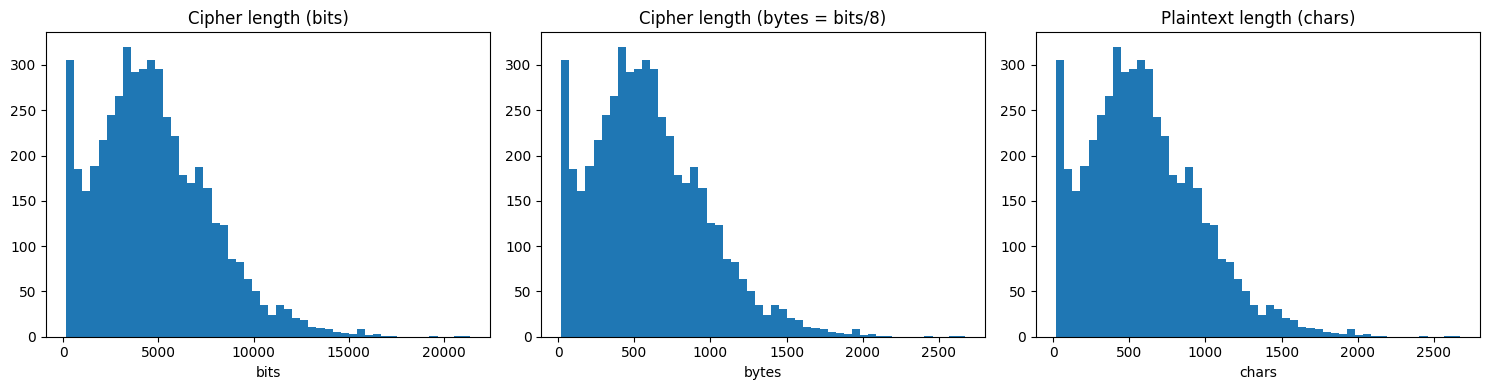

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cipher_bit_lens, bins=50)
axes[0].set_title("Cipher length (bits)")
axes[0].set_xlabel("bits")

axes[1].hist(cipher_byte_lens, bins=50)
axes[1].set_title("Cipher length (bytes = bits/8)")
axes[1].set_xlabel("bytes")

axes[2].hist(plain_char_lens, bins=50)
axes[2].set_title("Plaintext length (chars)")
axes[2].set_xlabel("chars")

plt.tight_layout()
plt.show()

### Corpus Idea

In [9]:
all_chars = set()
for l in plain_lines:
    all_chars.update(l)

print(f"unique characters in plaintext: {len(all_chars)}")
print(sorted(all_chars))

non_ascii = {c for c in all_chars if ord(c) > 127}
print(f"non-ASCII characters: {non_ascii if non_ascii else 'none'}")

unique characters in plaintext: 53
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
non-ASCII characters: none


In [10]:
def bits_to_bytes(bitstring):
    assert len(bitstring) % 8 == 0, "bit length not a multiple of 8"
    return bytes(int(bitstring[i:i+8], 2) for i in range(0, len(bitstring), 8))

for i in SAMPLE_IDXS:
    c, p = cipher_lines[i], plain_lines[i]
    if len(c) % 8 != 0:
        print(f"line {i}: cipher length not multiple of 8, skipping byte decode")
        continue
    raw_bytes = bits_to_bytes(c)
    try:
        decoded = raw_bytes.decode("utf-8")
        matches_plain = decoded == p
    except UnicodeDecodeError:
        decoded = None
        matches_plain = False
    print(f"line {i}: utf-8 decodable={decoded is not None}, matches plaintext={matches_plain}")
    if decoded is not None and not matches_plain:
        print(f"  decoded: {decoded[:80]!r}")
        print(f"  plain  : {p[:80]!r}")

line 0: utf-8 decodable=True, matches plaintext=False
  decoded: "\x13!.5@D\x12t.; $WB\x12_2n->\x12u\\Q-'?8\x12V[Z,n85^UD_2'#>\x12Q\\Ra:$5SD@Sa//$]B\x12~$n$1V\x10S\x16&;)#F\x10AB"
  plain  : 'Robert Boulter is an English film television and theatre actor He had a guest st'
line 1: utf-8 decodable=True, matches plaintext=False
  decoded: "\x08 l\x12]E^B$<l#FQ@D$*l1^_\\Q2'(5\x12gZ_2&-'\x12Y\\\x165&)pB\\SOa\r%$[JWX2&% \x12G@_5:)>\x12RK\x16\x0c/>;\x12bS@"
  plain  : 'In Boulter starred alongside Whishaw in the play Citizenship written by Mark Rav'
line 2: utf-8 decodable=True, matches plaintext=False
  decoded: '\x08 l\x12]E^B$<l8ST\x12Wa)95AD\x12E5/>"[^U\x163! 5\x12_\\\x165&)pFU^S7\'?9]^\x12E$<%5A\x10f^$n\x0e9^\\\x12^$n<?@D@W'
  plain  : 'In Boulter had a guest starring role on the television series The Bill he portra'
line 100: utf-8 decodable=True, matches plaintext=False
  decoded: '\x15&))\x12BWB4<"5V\x10ZY,+l?\\\x10xC/+l1\\T\x12B)+l\x19x~\x12T$)->\x12@@S-\'!9\\Q@Oa> 1\\^[X&n8?\x12BWF

## 8. Notes / conclusions

Fill in after running the cells above:

- Bits/char ratio: 8 
- Is cipher literally UTF-8 bytes of plaintext, or something else (XOR, substitution, etc.)? ______
- Max cipher bit length: 21360  → informs source max_seq_len
- Max plain char length: 2670  → informs target max_seq_len (subword) and byte-level target length for C5

### Huggingface commit trial

In [12]:
from huggingface_hub import upload_file
upload_file(
    path_or_fileobj= DATA_DIR / "brown_plain.txt",  # any throwaway local file
    path_in_repo="dummy.txt",
    repo_id="vibhav20/anlp-a1-transformer",
)

CommitInfo(commit_url='https://huggingface.co/vibhav20/anlp-a1-transformer/commit/443a644b106c0b57f33a2b868a82b6178fac8a1d', commit_message='Upload dummy.txt with huggingface_hub', commit_description='', oid='443a644b106c0b57f33a2b868a82b6178fac8a1d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/vibhav20/anlp-a1-transformer', endpoint='https://huggingface.co', repo_type='model', repo_id='vibhav20/anlp-a1-transformer'), pr_revision=None, pr_num=None)